# JAX tutorial and MFLD implementation

[JAX](https://docs.jax.dev/en/latest/notebooks/thinking_in_jax.html) is just like Numpy:

In [2]:
import jax.numpy as jnp  #jnp works with jax, np works with numpy, they are interchangeable in most cases
import numpy as np

with additional support for:

1. Automatic differentiation (useful for us when computing $\nabla_\theta \log p(y_i \mid \theta)$)
2. Faster loops and batching (useful for running MFLD quickly)

*Aside: JAX also supports GPU computation via cuda, but this feature is not supported on Windows currently.*

### Manipulating arrays with JAX

Effectively interchangeable with numpy code, e.g.

In [ ]:
x = jnp.array([1, 2, 3])  # create a jax array
y = jnp.array([4, 5, 6])   # create a numpy array

x + y # element-wise addition, works with both jax and numpy arrays
x * y # element-wise multiplication, works with both jax and numpy arrays
jnp.dot(x, y) # dot product, works with both jax and numpy arrays
jnp.sum(x) # sum of elements, works with both jax and numpy arrays
jnp.mean(x) # mean of elements, works with both jax and numpy arrays
jnp.sqrt(x) # square root, works with both jax and numpy arrays
jnp.exp(x) # exponential, works with both jax and numpy arrays
jnp.log(x) # natural logarithm, works with both jax and numpy arrays
jnp.sin(x) # sine function, works with both jax and numpy arrays
jnp.cos(x) # cosine function, works with both jax and numpy arrays
jnp.tan(x) # tangent function, works with both jax and numpy arrays
jnp.arcsin(x) # inverse sine function, works with both jax and numpy arrays
jnp.arccos(x) # inverse cosine function, works with both jax and

### Automatic differentiation with JAX

JAX's syntax for computing derivatives can be a little confusing at first. See [this](https://docs.jax.dev/en/latest/automatic-differentiation.html) tutorial for an introduction. 

The basic structure is:

In [3]:
import jax
from jax import grad

grad_sin = grad(jnp.sin)  # compute the gradient of the sine function
print(grad_sin(0.0))  # should be close to 1.

grad_cos = grad(jnp.cos)  # compute the gradient of the cosine function
print(grad_cos(0.0))  # should be close to 0.

1.0
-0.0


## Suggested Structure of MFLD Code

Mean-Field Langevin Dynamics (MFLD) is used to compute a **predictively oriented posterior**, which is a post-Bayesian alternative to the standard Bayesian posterior designed to improve predictive performance under model misspecification.

More precisely, MFLD solves the variational problem

$$
\argmin_{Q \in \mathcal{P}(\mathbb{R}^d)}
\;
\mathcal{L}(Q)
+
\mathrm{KLD}(Q \,\|\, Q_0)
$$

where

$$
\mathrm{KLD}(Q \,\|\, Q_0)
=
\int
\log \frac{\mathrm{d}Q}{\mathrm{d}Q_0}
\;
\mathrm{d}Q
$$

and the **predictive loss** is

$$
\mathcal{L}(Q)
=
-
\sum_{i=1}^n
\log
\int
p(y_i \mid \theta)
\;
\mathrm{d}Q(\theta).
$$

---

### Required components

In order to run Mean-Field Langevin Dynamics (MFLD), we require three main components:

#### 1. Model

The **Model** defines the statistical model and must provide:

1. Likelihood evaluation

   $$
   p(y_i \mid x_i, \theta)
   $$

   or equivalently the log-likelihood

   $$
   \log p(y_i \mid x_i, \theta)
   $$

2. Gradient of the log-likelihood

   $$
   \nabla_\theta
   \log p(y_i \mid x_i, \theta)
   $$

   This can be computed automatically in JAX using automatic differentiation.

3. Prior density

   $$
   p(\theta)
   $$

   and its gradient

   $$
   \nabla_\theta \log p(\theta)
   $$

The Model is most naturally implemented as a **class**. This allows all model-specific functionality (likelihood, prior, gradients) to be encapsulated in a single object.


### 2. Data

The **Data** consists of observed input-output pairs:

$$
\{(x_i, y_i)\}_{i=1}^n
$$

In code, this would typically be stored as arrays:

$$
X = (x_1, \dots, x_n), \qquad
Y = (y_1, \dots, y_n)
$$

### 3. MFLD Parameters

These control the particle system:

- Number of particles: $M$
- Step size: $\varepsilon$
- Number of iterations: $T$


### Implementing the Model Class

The following implements an abstract class of a **Model**. The key advantage from JAX is that the `grad_log_probs` can be computed automatically using JAX's automatic differentiation capabilities:

In [ ]:
import jax 

import jax
import jax.numpy as jnp


class Model:
    """
    Minimal abstract model class for MFLD.

    Conventions:
    - y has n observations (shape (n, ...) )
    - x is optional covariates for regression (shape (n, ...) ) or None
    - theta is either a single parameter vector (d,) or a batch of particles (M, d)

    Optional methods:
        sample(theta, key, x=None)   # generate synthetic data
        sample_prior(shape, key)          # sample from the prior distribution 

    Required methods:
        log_probs(y, theta, x=None)
        log_prior(theta)
    """

    def log_probs(self, y, theta, x=None):
        """Return log-likelihood matrix L with shape (n, M)."""
        raise NotImplementedError("Implement in a subclass.")

    def log_prior(self, theta):
        """Return log p(theta). If theta is (M, d), return shape (M,)."""
        raise NotImplementedError("Implement in a subclass.")

    def grad_log_probs(self, y, theta, x=None):
        """
        Return gradients of log-likelihood wrt theta.

        Output shape:
        - if theta is (M, d): returns (n, M, d)
        - if theta is (d,): returns (n, d)  (single particle)
        """
        # Force theta to be batched: (M, d)
        single = (theta.ndim == 1)
        theta_batched = theta[None, :] if single else theta  # (M, d)

        def log_probs_single(theta_j):
            # theta_j is (d,) -> return (n,)
            lp = self.log_probs(y=y, x=x, theta=theta_j)
            if lp.ndim == 2:      # e.g. (n, 1)
                lp = lp[:, 0]
            return lp             # (n,)

        # For each particle j: jacobian of (n,) wrt (d,) gives (n, d)
        per_particle = jax.vmap(jax.jacfwd(log_probs_single))(theta_batched)  # (M, n, d)
        grads = jnp.transpose(per_particle, (1, 0, 2))  # (n, M, d)

        return grads[:, 0, :] if single else grads

    def grad_log_prior(self, theta):
        """
        Return gradient of log prior wrt theta.

        Output shape:
        - if theta is (M, d): returns (M, d)
        - if theta is (d,): returns (d,)
        """
        if theta.ndim == 1:
            return jax.grad(lambda th: jnp.sum(self.log_prior(th)))(theta)

        return jax.vmap(jax.grad(lambda th: jnp.sum(self.log_prior(th))))(theta)


    # -------------------------
    # Optional sample method for synthetic data generation
    # -------------------------

    def sample(self, theta, key, x=None):
        """
        Generate synthetic observations from the model.

        Returns:
            y

        Not required for MFLD itself, but useful for toy examples.
        """
        raise NotImplementedError("Sampling not implemented for this model.")
    
    def sample_prior(self, key, num_particles, dim):
        """
        Generate samples from the prior distribution.

        Returns:
            theta
        """
        raise NotImplementedError("Sampling of prior not implemented for this model.")


To actually use this, we need to define a subclass which implements the `log_probs` function. Here is an implementation of your logistic regression:

In [ ]:
class LogisticRegressionModel(Model):

    def __init__(self, prior_variance=1.0):

        self.prior_variance = prior_variance
        self.prior_std = jnp.sqrt(prior_variance)
        self.prior_precision = 1.0 / prior_variance



    def log_probs(self, y, theta, x=None):

        X = x
        y = y.reshape(-1)

        single = (theta.ndim == 1)
        theta = theta[None, :] if single else theta

        eta = X @ theta.T

        loglik = y[:, None] * eta - jax.nn.softplus(eta)

        return loglik


    def log_prior(self, theta):

        """
        Log density of N(0, sigma^2 I) (constant omitted)
        """

        precision = self.prior_precision

        if theta.ndim == 1:
            return -0.5 * precision * jnp.sum(theta**2)

        return -0.5 * precision * jnp.sum(theta**2, axis=1)


    def sample(self, theta, key, x=None):

        logits = x @ theta

        probs = jax.nn.sigmoid(logits)

        return jax.random.bernoulli(key, probs).astype(jnp.float32)


    def sample_prior(self, key, num_particles, dim):
        return self.prior_std * jax.random.normal(key, (num_particles, dim))


### MFLD code

For iterations $t = 0, \dots, T-1$ and particles $i = 1, \dots, M$:

$$
\theta_{t+1}^{(i)}
=
\theta_t^{(i)}
+
\varepsilon
\left[
\nabla_\theta \log q_0(\theta_t^{(i)})
+
\sum_{k=1}^n
\frac{
p(y_k \mid \theta_t^{(i)})
\nabla_\theta \log p(y_k \mid \theta_t^{(i)})
}{
\frac{1}{M}
\sum_{j=1}^M
p(y_k \mid \theta_t^{(j)})
}
\right]
+
\sqrt{2\varepsilon}
\, Z_t^{(i)}
$$

where $q_0$ is the prior density and

$$
Z_t^{(i)} \sim \mathcal{N}(0, I).
$$


We need to refactor the MFLD code so that it expects the **Model** class. The following does so using "vanilla" Python for-loops (slow):

In [15]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp


def mfld_run_slow(
    model, y, x, *, num_particles, step_size, num_steps, key,
    theta0=None, record_every=1, noise_scale=1.0
):
    eps = step_size
    M = num_particles
    T = num_steps

    # init
    if theta0 is None:
        if x is None:
            raise ValueError("If theta0 is None, x must be provided to infer dim.")
        d = x.shape[1]
        if hasattr(model, "sample_prior"):
            theta = model.sample_prior(key, num_particles=M, dim=d)
        else:
            theta = jax.random.normal(key, (M, d))
    else:
        theta = theta0

    keys = jax.random.split(key, T)

    trajs, means, stds = [], [], []

    for t in range(T):
        # L: (n, M)
        L = model.log_probs(y=y, x=x, theta=theta)

        # log denom_i = log( (1/M) sum_j exp(L_ij) )
        log_denom = logsumexp(L, axis=1) - jnp.log(M)   # (n,)

        # weights_ik = exp(L_ik - log_denom_i)  (n, M)
        weights = jnp.exp(L - log_denom[:, None])

        # G: (n, M, d)
        G = model.grad_log_probs(y=y, x=x, theta=theta)

        # interaction: (M, d)  sum_i weights_ik * G_ik
        interaction = jnp.sum(weights[:, :, None] * G, axis=0)

        grad_prior = model.grad_log_prior(theta)  # (M, d)

        z = jax.random.normal(keys[t], theta.shape)

        theta = theta + eps * (grad_prior + interaction) + noise_scale * jnp.sqrt(2.0 * eps) * z

        if (t % record_every) == 0:
            trajs.append(theta)
            means.append(jnp.mean(theta, axis=0))
            stds.append(jnp.std(theta, axis=0))

    stats = {
        "traj": jnp.stack(trajs, axis=0) if trajs else None,
        "mean": jnp.stack(means, axis=0) if means else None,
        "std": jnp.stack(stds, axis=0) if stds else None,
    }
    return theta, stats


JAX also provides us a way to evaluate for-loops in a fast way. Here is the MFLD code implemented in this manner:

In [ ]:
import jax
import jax.numpy as jnp
from jax.scipy.special import logsumexp


def mfld_step(model, y, x, theta, key, eps, noise_scale=1.0):
    """
    One MFLD step (predictive-corrected / PC objective).

    theta: (M, d)
    key: PRNGKey
    returns: theta_next (M, d)
    """
    M = theta.shape[0]

    # L: (n, M) with L[i,k] = log p(y_i | x_i, theta_k)
    L = model.log_probs(y=y, x=x, theta=theta)

    # log denom_i = log( (1/M) sum_j exp(L_ij) )
    log_denom = logsumexp(L, axis=1) - jnp.log(M)  # (n,)

    # weights_ik = p(y_i|theta_k) / mean_j p(y_i|theta_j)
    weights = jnp.exp(L - log_denom[:, None])      # (n, M)

    # G: (n, M, d) with G[i,k,:] = ∇_θ log p(y_i | x_i, theta_k)
    G = model.grad_log_probs(y=y, x=x, theta=theta)

    # interaction[k,:] = sum_i weights[i,k] * G[i,k,:]
    interaction = jnp.sum(weights[:, :, None] * G, axis=0)  # (M, d)

    # prior gradient: ∇ log q0(theta)
    grad_prior = model.grad_log_prior(theta)  # (M, d)

    # noise
    z = jax.random.normal(key, theta.shape)

    # update (PC drift uses + interaction)
    theta_next = theta + eps * (grad_prior + interaction) + noise_scale * jnp.sqrt(2.0 * eps) * z
    return theta_next


def mfld_run(
    model, y, x, *, num_particles, step_size, num_steps, key,
    theta0=None, record_every=1, noise_scale=1.0
):
    """
    JAX-looped MFLD run using `jax.lax.scan`.

    Returns:
        theta_final: (M, d)
        stats:
            - "mean": (K, d) mean(theta) every record_every steps
            - "std":  (K, d) std(theta)  every record_every steps
    """
    eps = step_size
    M = num_particles
    T = num_steps

    # ---- init particles ----
    if theta0 is None:
        if x is None:
            raise ValueError("If theta0 is None, x must be provided to infer dim.")
        d = x.shape[1]
        if hasattr(model, "sample_prior"):
            theta0 = model.sample_prior(key, num_particles=M, dim=d)
        else:
            theta0 = jax.random.normal(key, (M, d))

    # Split keys: one per step
    keys = jax.random.split(key, T)

    def scan_body(theta, inputs):
        k, t = inputs
        theta = mfld_step(model, y, x, theta, k, eps, noise_scale=noise_scale)

        # record mean/std at chosen frequency, otherwise write NaNs (easy to filter later)
        do_record = (t % record_every) == 0
        mean_t = jnp.where(do_record, jnp.mean(theta, axis=0), jnp.nan)
        std_t  = jnp.where(do_record, jnp.std(theta, axis=0),  jnp.nan)

        aux = (mean_t, std_t)
        return theta, aux

    ts = jnp.arange(T)
    theta_final, (mean_hist, std_hist) = jax.lax.scan(
        scan_body,
        theta0,
        (keys, ts),
    )

    is_kept = ~jnp.isnan(mean_hist).any(axis=1)
    mean_hist = mean_hist[is_kept]
    std_hist  = std_hist[is_kept]

    stats = {"mean": mean_hist, "std": std_hist}
    return theta_final, stats


### Comparing outputs:

##### Python For-loop version

This takes around 20 seconds for me:

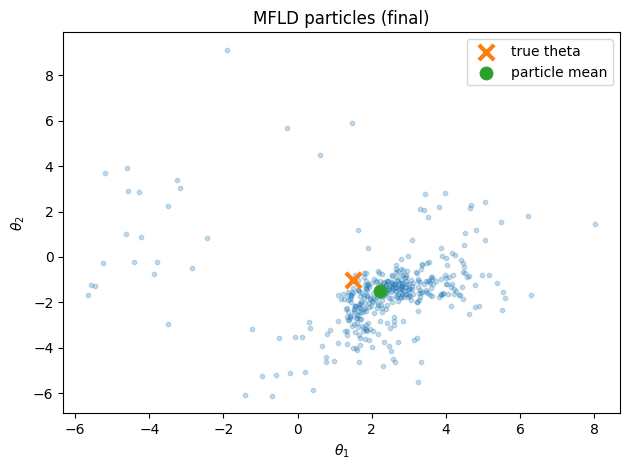

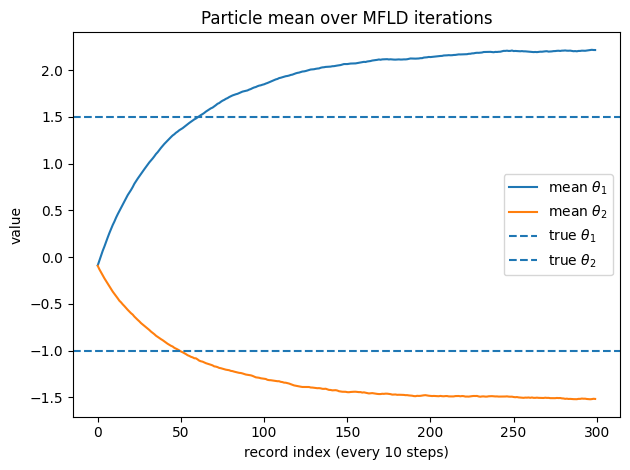

In [16]:
from matplotlib import pyplot as plt

key = jax.random.PRNGKey(0)
key, kx, kt, ky, km = jax.random.split(key, 5)

# synthetic dataset (choose d=2 so we can scatter-plot particles)
n = 500
d = 2
X = jax.random.normal(kx, (n, d))

theta_true = jnp.array([1.5, -1.0])
model = LogisticRegressionModel(prior_variance=5.0)

y = model.sample(theta_true, ky, x=X)

# run MFLD
M = 400
eps = 1e-4
T = 3000

theta_final, stats = mfld_run_slow(
    model,
    y,
    X,
    num_particles=M,
    step_size=eps,
    num_steps=T,
    key=km,
    record_every=10,
)

theta_final_np = jax.device_get(theta_final)
mean_traj = jax.device_get(stats["mean"])

#  particle cloud +  true theta + particle mean
plt.figure()
plt.scatter(theta_final_np[:, 0], theta_final_np[:, 1], s=10, alpha=0.25)
plt.scatter([theta_true[0]], [theta_true[1]], marker="x", s=120, linewidths=3, label="true theta")
plt.scatter([mean_traj[-1, 0]], [mean_traj[-1, 1]], marker="o", s=80, label="particle mean")
plt.title("MFLD particles (final)")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend()
plt.tight_layout()

# trajectory of particle mean components
plt.figure()
plt.plot(mean_traj[:, 0], label=r"mean $\theta_1$")
plt.plot(mean_traj[:, 1], label=r"mean $\theta_2$")
plt.axhline(float(theta_true[0]), linestyle="--", label=r"true $\theta_1$")
plt.axhline(float(theta_true[1]), linestyle="--", label=r"true $\theta_2$")
plt.title("Particle mean over MFLD iterations")
plt.xlabel("record index (every 10 steps)")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

plt.show()


##### JAX recursion (fast)

This takes around 3.1 seconds for me (mainly the plotting code):

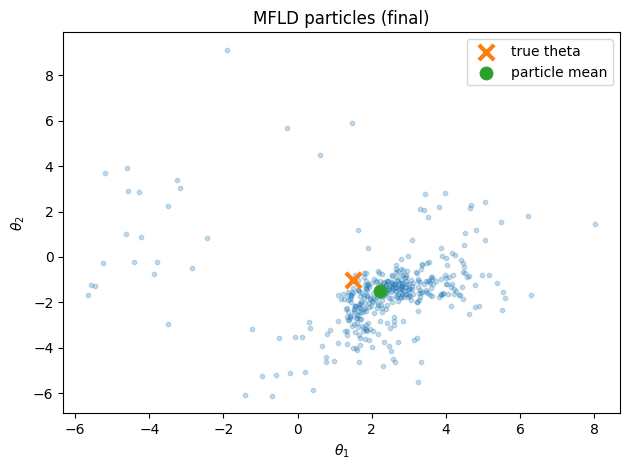

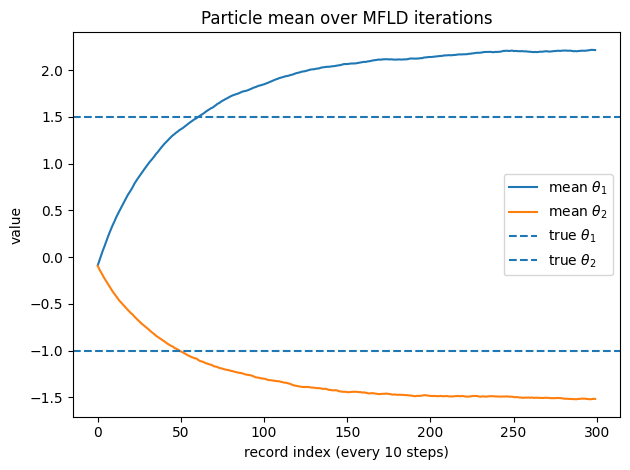

In [17]:
from matplotlib import pyplot as plt

key = jax.random.PRNGKey(0)
key, kx, kt, ky, km = jax.random.split(key, 5)

# synthetic dataset (choose d=2 so we can scatter-plot particles)
n = 500
d = 2
X = jax.random.normal(kx, (n, d))

theta_true = jnp.array([1.5, -1.0])
model = LogisticRegressionModel(prior_variance=5.0)

y = model.sample(theta_true, ky, x=X)

# run MFLD
M = 400
eps = 1e-4
T = 3000

theta_final, stats = mfld_run(
    model,
    y,
    X,
    num_particles=M,
    step_size=eps,
    num_steps=T,
    key=km,
    record_every=10,
)

theta_final_np = jax.device_get(theta_final)
mean_traj = jax.device_get(stats["mean"])

#  particle cloud +  true theta + particle mean
plt.figure()
plt.scatter(theta_final_np[:, 0], theta_final_np[:, 1], s=10, alpha=0.25)
plt.scatter([theta_true[0]], [theta_true[1]], marker="x", s=120, linewidths=3, label="true theta")
plt.scatter([mean_traj[-1, 0]], [mean_traj[-1, 1]], marker="o", s=80, label="particle mean")
plt.title("MFLD particles (final)")
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.legend()
plt.tight_layout()

# trajectory of particle mean components
plt.figure()
plt.plot(mean_traj[:, 0], label=r"mean $\theta_1$")
plt.plot(mean_traj[:, 1], label=r"mean $\theta_2$")
plt.axhline(float(theta_true[0]), linestyle="--", label=r"true $\theta_1$")
plt.axhline(float(theta_true[1]), linestyle="--", label=r"true $\theta_2$")
plt.title("Particle mean over MFLD iterations")
plt.xlabel("record index (every 10 steps)")
plt.ylabel("value")
plt.legend()
plt.tight_layout()

plt.show()
